# Transformer Forecasting

## Update Notice

The corrected Transformer implementation is included near the end of this notebook under `## 13. Corrected Transformer Model`. It keeps the existing `## Transformer Failure Analysis` section and adds a fixed encoder that projects the 1D input into `d_model=64` before attention and `LayerNormalization`.

## 1. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    Input,
    LayerNormalization,
    MultiHeadAttention,
)
from tensorflow.keras.models import Model, Sequential

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

tf.random.set_seed(42)
np.random.seed(42)

## 2. Load Dataset

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"

df_raw = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(df_raw)
target = df_daily["Close"].dropna().asfreq("D")

df_daily.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00+00:00,4.58,5.00,4.58,5.00,21.602000
2012-01-02 00:00:00+00:00,5.00,5.00,5.00,5.00,19.048000
2012-01-03 00:00:00+00:00,5.00,5.32,5.00,5.29,88.037281
2012-01-04 00:00:00+00:00,5.29,5.57,4.93,5.57,107.233260
2012-01-05 00:00:00+00:00,5.57,6.65,5.57,6.65,94.801829


## 3. Train-Test Split

In [3]:
split_idx = int(len(target) * 0.8)

train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

train.shape, test.shape

((4241,), (1061,))

## 4. Data Preparation

In [4]:
LOOKBACK = 30

scaler = MinMaxScaler(feature_range=(0, 1))
train_values = train.to_numpy().reshape(-1, 1)
test_values = test.to_numpy().reshape(-1, 1)

train_scaled = scaler.fit_transform(train_values)
test_scaled = scaler.transform(test_values)


def create_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback : i])
        y.append(values[i])
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, LOOKBACK)
combined_scaled = np.vstack([train_scaled[-LOOKBACK:], test_scaled])
X_test, y_test_scaled = create_sequences(combined_scaled, LOOKBACK)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4211, 30, 1), (4211, 1), (1061, 30, 1), (1061,))

## 5. Transformer Model

In [5]:
def transformer_encoder(inputs, head_size=32, num_heads=2, ff_dim=32, dropout=0.1):
    attention_output = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
    )(inputs, inputs)
    attention_output = Dropout(dropout)(attention_output)
    attention_output = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    feed_forward = Dense(ff_dim, activation="relu")(attention_output)
    feed_forward = Dropout(dropout)(feed_forward)
    feed_forward = Dense(inputs.shape[-1])(feed_forward)
    return LayerNormalization(epsilon=1e-6)(attention_output + feed_forward)


inputs = Input(shape=(LOOKBACK, 1))
x = transformer_encoder(inputs)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.1)(x)
x = Dense(32, activation="relu")(x)
outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │        449 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 1)     │          0 │ input_layer[0][0… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │         64 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 32)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 1)     │         33 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1)         │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │         64 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 647 (2.53 KB)

 Trainable params: 647 (2.53 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

Epoch 1/20


  1/119 ━━━━━━━━━━━━━━━━━━━━ 11:07 6s/step - loss: 2.8661e-10

  8/119 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5274e-07  

 15/119 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.8798e-07

 23/119 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.8824e-06

...

 93/119 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0141

100/119 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0132

107/119 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0295

114/119 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0485

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0534 - val_loss: 0.0423


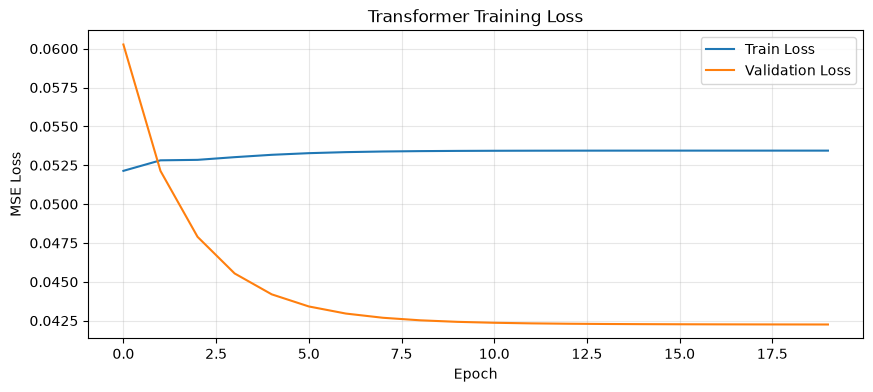

In [6]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

history = transformer_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    shuffle=False,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Validation Loss")
ax.set_title("Transformer Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 7. Forecast Generation

 1/34 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step

16/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


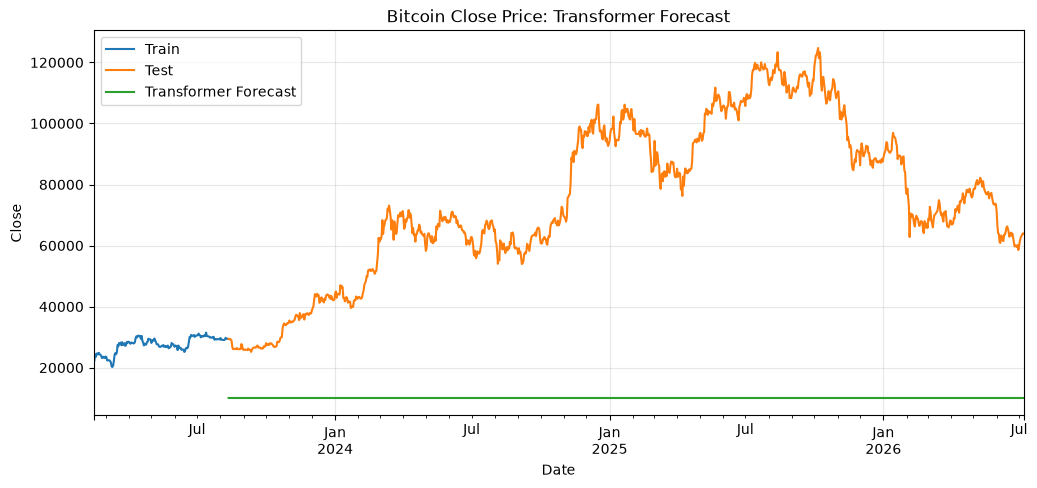

In [7]:
transformer_predictions_scaled = transformer_model.predict(X_test)
transformer_predictions = scaler.inverse_transform(transformer_predictions_scaled).ravel()
transformer_forecast = pd.Series(
    transformer_predictions,
    index=test.index,
    name="Transformer",
)

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
transformer_forecast.plot(ax=ax, label="Transformer Forecast")
ax.set_title("Bitcoin Close Price: Transformer Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 8. Evaluation Metrics

In [8]:
def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }


transformer_metrics = pd.DataFrame(
    [evaluate_forecast(y_test, transformer_forecast)],
    index=["Transformer"],
)

transformer_metrics

,MAE,RMSE,MAPE,sMAPE
Transformer,65122.605617,69956.202009,84.34469,147.167945


## 9. Comparison with Classical Models

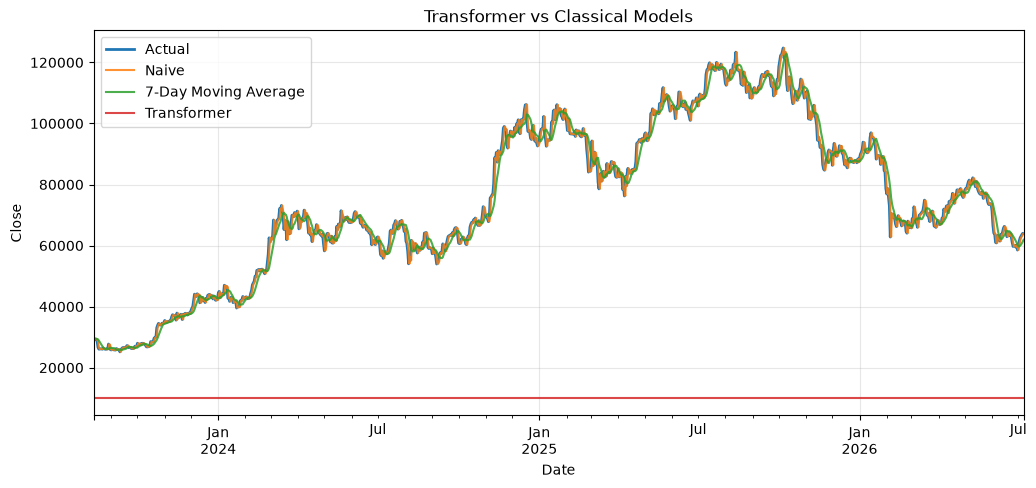

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Transformer,65122.605617,69956.202009,84.344690,147.167945


In [9]:
naive_forecast = target.shift(1).reindex(test.index).rename("Naive")
moving_average_forecast = (
    target.shift(1)
    .rolling(window=7)
    .mean()
    .reindex(test.index)
    .rename("7-Day Moving Average")
)

classical_forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Transformer": transformer_forecast,
}

classical_comparison = pd.DataFrame(
    [evaluate_forecast(y_test, forecast) for forecast in classical_forecasts.values()],
    index=classical_forecasts.keys(),
)

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in classical_forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("Transformer vs Classical Models")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

classical_comparison.sort_values("RMSE")

## 10. Comparison with LSTM Models

Epoch 1/20


  1/119 ━━━━━━━━━━━━━━━━━━━━ 4:32 2s/step - loss: 2.3922e-10

  7/119 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2844e-05 

 13/119 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.8900e-06

 18/119 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.9127e-06

...

24/34 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

27/34 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

30/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


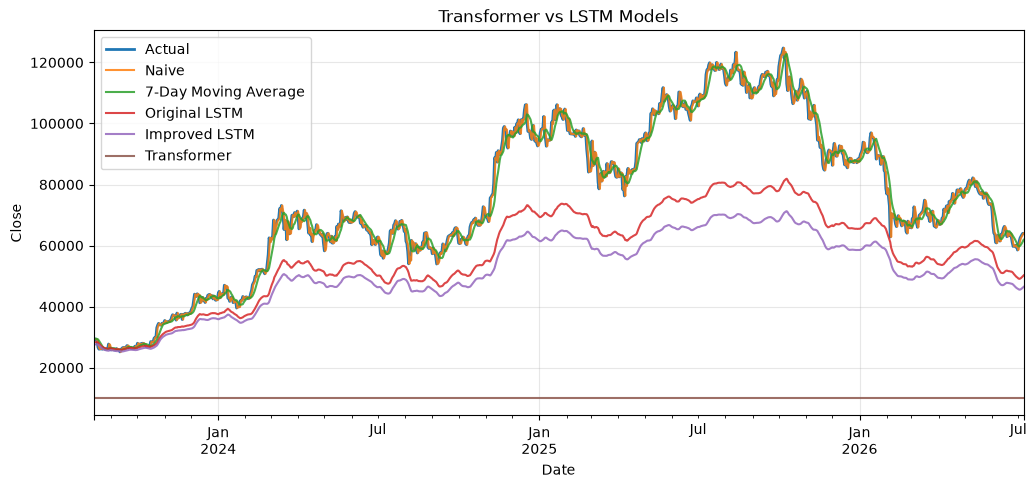

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Original LSTM,17999.812391,20912.972998,21.419551,24.421117
Improved LSTM,23436.695846,27049.622966,27.972044,33.257138
Transformer,65122.605617,69956.202009,84.344690,147.167945


In [10]:
def fit_lstm_forecast(lookback, layers):
    X_train_lstm, y_train_lstm = create_sequences(train_scaled, lookback)
    combined_lstm = np.vstack([train_scaled[-lookback:], test_scaled])
    X_test_lstm, _ = create_sequences(combined_lstm, lookback)

    model = Sequential(layers)
    model.compile(optimizer="adam", loss="mse")
    callback = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        callbacks=[callback],
        shuffle=False,
    )
    predictions_scaled = model.predict(X_test_lstm)
    predictions = scaler.inverse_transform(predictions_scaled).ravel()
    return pd.Series(predictions, index=test.index)


original_lstm_forecast = fit_lstm_forecast(
    lookback=30,
    layers=[
        Input(shape=(30, 1)),
        tf.keras.layers.LSTM(32),
        Dense(1),
    ],
).rename("Original LSTM")

improved_lstm_forecast = fit_lstm_forecast(
    lookback=60,
    layers=[
        Input(shape=(60, 1)),
        tf.keras.layers.LSTM(64, return_sequences=True),
        Dropout(0.2),
        tf.keras.layers.LSTM(32),
        Dropout(0.2),
        Dense(1),
    ],
).rename("Improved LSTM")

lstm_forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Original LSTM": original_lstm_forecast,
    "Improved LSTM": improved_lstm_forecast,
    "Transformer": transformer_forecast,
}

lstm_comparison = pd.DataFrame(
    [evaluate_forecast(y_test, forecast) for forecast in lstm_forecasts.values()],
    index=lstm_forecasts.keys(),
)

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in lstm_forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("Transformer vs LSTM Models")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

lstm_comparison.sort_values("RMSE")

## 11. Key Findings

- This notebook starts with a compact Transformer encoder using a 30-day lookback window.
- Naive and 7-day moving average forecasts remain important classical baselines for persistent Bitcoin prices.
- Original and improved LSTM baselines are trained in-notebook so the Transformer is compared on the same split and test period.
- Lower MAE, RMSE, MAPE, and sMAPE values indicate stronger out-of-sample performance.

## 12. Transformer Diagnostics

First 10 actual values:
Timestamp
2023-08-12 00:00:00+00:00    29415.0
2023-08-13 00:00:00+00:00    29284.0
2023-08-14 00:00:00+00:00    29408.0
2023-08-15 00:00:00+00:00    29172.0
2023-08-16 00:00:00+00:00    28701.0
2023-08-17 00:00:00+00:00    26642.0
2023-08-18 00:00:00+00:00    26051.0
2023-08-19 00:00:00+00:00    26097.0
2023-08-20 00:00:00+00:00    26192.0
2023-08-21 00:00:00+00:00    26125.0
Freq: D

First 10 Transformer predictions:
Timestamp
2023-08-12 00:00:00+00:00    10048.5
2023-08-13 00:00:00+00:00    10048.5
2023-08-14 00:00:00+00:00    10048.5
2023-08-15 00:00:00+00:00    10048.5
2023-08-16 00:00:00+00:00    10048.5
2023-08-17 00:00:00+00:00    10048.5
2023-08-18 00:00:00+00:00    10048.5
2023-08-19 00:00:00+00:00    10048.5
2023-08-20 00:00:00+00:00    10048.5
2023-08-21 00:00:00+00:00    10048.5
Freq: D

First 10 Naive predictions:
Timestamp
2023-08-12 00:00:00+00:00    29398.0
2023-08-13 00:00:00+00:00    29415.0
2023-08-14 00:00:00+00:00    29284.0
2023-08-15 00:0

E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


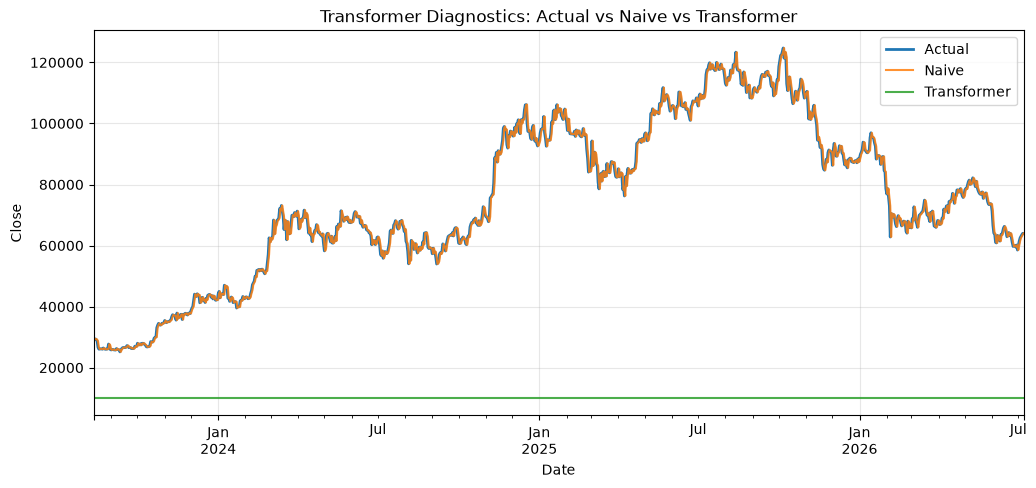

In [11]:
diagnostics = pd.DataFrame(
    {
        "Actual": y_test,
        "Transformer": transformer_forecast,
        "Naive": naive_forecast,
    }
)

print("First 10 actual values:")
print(y_test.head(10).to_string())

print("\nFirst 10 Transformer predictions:")
print(transformer_forecast.head(10).to_string())

print("\nFirst 10 Naive predictions:")
print(naive_forecast.head(10).to_string())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Scaling range:", scaler.feature_range)
print("Train scaled min/max:", float(train_scaled.min()), float(train_scaled.max()))
print("Test scaled min/max:", float(test_scaled.min()), float(test_scaled.max()))

print("\nTraining loss history:")
print(pd.DataFrame(history.history).to_string(index=False))

print("\nPrediction distribution checks:")
print("Actual mean:", y_test.mean())
print("Transformer prediction mean:", transformer_forecast.mean())
print("Actual std:", y_test.std())
print("Transformer prediction std:", transformer_forecast.std())
print("Correlation(actual, prediction):", y_test.corr(transformer_forecast))

rescaled_predictions = scaler.transform(transformer_forecast.to_numpy().reshape(-1, 1))
inverse_scaling_ok = np.allclose(
    rescaled_predictions,
    transformer_predictions_scaled,
    rtol=1e-5,
    atol=1e-6,
)
print("\nInverse scaling check passed:", inverse_scaling_ok)

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.plot(ax=ax, label="Naive", alpha=0.85)
transformer_forecast.plot(ax=ax, label="Transformer", alpha=0.85)
ax.set_title("Transformer Diagnostics: Actual vs Naive vs Transformer")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

A very poor Transformer result can come from several sources. The inverse-scaling check helps rule out a common implementation error in converting scaled predictions back to prices. If inverse scaling is correct but predictions have a mean far from the actual test mean, low variance, or weak correlation with actual prices, the result is more likely due to undertraining and model limitation. This compact encoder has little feature context, a short training budget, and no explicit trend or volatility inputs, so it may underfit Bitcoin's noisy, regime-dependent price dynamics and fail to beat the one-step naive benchmark.

In [12]:
print("\nTransformer forecast min/max:")
print(transformer_forecast.min(), transformer_forecast.max())

print("\nActual min/max:")
print(y_test.min(), y_test.max())

print("\nTransformer daily-change std / Actual daily-change std:")
print(transformer_forecast.diff().std() / y_test.diff().std())


Transformer forecast min/max:
10048.5 10048.5

Actual min/max:
25155.0 124728.0

Transformer daily-change std / Actual daily-change std:
0.0


## Transformer Failure Analysis

In [13]:
print("Transformer model summary:")
transformer_model.summary()

final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]
predictions_scaled_flat = transformer_predictions_scaled.ravel()
predictions_unscaled_flat = transformer_forecast.to_numpy()
scaled_constant = np.allclose(
    predictions_scaled_flat,
    predictions_scaled_flat[0],
    rtol=1e-7,
    atol=1e-8,
)
unscaled_constant = np.allclose(
    predictions_unscaled_flat,
    predictions_unscaled_flat[0],
    rtol=1e-7,
    atol=1e-8,
)

print("\nFinal train loss:", final_train_loss)
print("Final validation loss:", final_val_loss)
print("Prediction std before inverse scaling:", predictions_scaled_flat.std())
print("Prediction std after inverse scaling:", predictions_unscaled_flat.std())
print("Prediction min before inverse scaling:", predictions_scaled_flat.min())
print("Prediction max before inverse scaling:", predictions_scaled_flat.max())
print("Prediction min after inverse scaling:", predictions_unscaled_flat.min())
print("Prediction max after inverse scaling:", predictions_unscaled_flat.max())
print("Predictions are not constant before inverse scaling:", not scaled_constant)
print("Predictions are not constant after inverse scaling:", not unscaled_constant)

print("\nArchitecture checks:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Input feature dimension:", X_train.shape[-1])
print("Transformer model input shape:", transformer_model.input_shape)
print("Transformer model output shape:", transformer_model.output_shape)
print("Feed-forward projection dimension:", X_train.shape[-1])

print("\nCollapse diagnosis:")
if scaled_constant and unscaled_constant:
    print(
        "Predictions are numerically constant before and after inverse scaling, so inverse scaling is not the cause."
    )
    print(
        "The encoder applies LayerNormalization over the final feature axis after projecting back to one feature."
    )
    print(
        "Because each timestep has only one feature, LayerNormalization normalizes each scalar with zero variance."
    )
    print(
        "That collapses the encoder representation to a constant tensor, leaving the Dense output head to learn a constant bias."
    )
elif unscaled_constant:
    print(
        "Predictions become constant after inverse scaling; inspect the scaler and prediction precision before changing the model."
    )
else:
    print(
        "Predictions are not constant at one or both stages; investigate training dynamics and scaling further."
    )


Transformer model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │        449 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 1)     │          0 │ input_layer[0][0… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │         64 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 32)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 1)     │         33 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1)         │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │         64 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,943 (7.59 KB)

 Trainable params: 647 (2.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,296 (5.07 KB)


Final train loss: 0.05344225838780403
Final validation loss: 0.042254216969013214
Prediction std before inverse scaling: 1.4901161e-08
Prediction std after inverse scaling: 0.0
Prediction min before inverse scaling: 0.14868335
Prediction max before inverse scaling: 0.14868335
Prediction min after inverse scaling: 10048.5
Prediction max after inverse scaling: 10048.5
Predictions are not constant before inverse scaling: False
Predictions are not constant after inverse scaling: False

Architecture checks:
X_train shape: (4211, 30, 1)
X_test shape: (1061, 30, 1)
Input feature dimension: 1
Transformer model input shape: (None, 30, 1)
Transformer model output shape: (None, 1)
Feed-forward projection dimension: 1

Collapse diagnosis:
Predictions are numerically constant before and after inverse scaling, so inverse scaling is not the cause.
The encoder applies LayerNormalization over the final feature axis after projecting back to one feature.
Because each timestep has only one feature, Layer

The Transformer collapse is an implementation issue in the current architecture, not an inverse-scaling issue. The predictions are already numerically constant before inverse scaling, and the inverse-scaling round-trip check above confirms that scaling is behaving consistently. The sequence generation and training loop produce non-empty train/test tensors and a fitted history, but the encoder projects the feed-forward block back to `inputs.shape[-1]`, which is `1`, then applies `LayerNormalization` over that single-feature axis. With only one value to normalize per timestep, the variance is zero and the normalized representation becomes constant. After global average pooling, the output layer can only learn a nearly constant bias, which explains the flat forecast. A corrected Transformer should first project the one-dimensional price input into a wider model dimension before attention and normalization, keep that wider representation through the encoder, and only project back to a scalar at the final output layer.

## 13. Corrected Transformer Model

The corrected model projects the one-dimensional price sequence into a wider `d_model` representation before applying attention, residual connections, and layer normalization. This avoids normalizing over a single-feature axis inside the Transformer encoder. The model only projects back to a single value at the final `Dense(1)` output layer.

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 64)    │        128 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ dense_6[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ dense_6[0][0],    │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 30, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         33 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,713 (139.50 KB)

 Trainable params: 35,713 (139.50 KB)

 Non-trainable params: 0 (0.00 B)

...

19/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

28/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


First 10 actual values:
Timestamp
2023-08-12 00:00:00+00:00    29415.0
2023-08-13 00:00:00+00:00    29284.0
2023-08-14 00:00:00+00:00    29408.0
2023-08-15 00:00:00+00:00    29172.0
2023-08-16 00:00:00+00:00    28701.0
2023-08-17 00:00:00+00:00    26642.0
2023-08-18 00:00:00+00:00    26051.0
2023-08-19 00:00:00+00:00    26097.0
2023-08-20 00:00:00+00:00    26192.0
2023-08-21 00:00:00+00:00    26125.0
Freq: D

First 10 corrected Transformer predictions:
Timestamp
2023-08-12 00:00:00+00:00    40562.566406
2023-08-13 00:00:00+00:00    40558.128906
2023-08-14 00:00:00+00:00    40555.980469
2023-08-15 00:00:00+00:00    40554.148438
2023-08-16 00:00:00+00:00    40551.906250
2023-08-17 00:00:00+00:00    40548.875000
2023-08-18 00:00:00+00:00    40541.722656
2023-08-19 00:00:00+00:00    40533.007812
2023-08-20 00:00:00+00:00    40524.640625
2023-08-21 00:00:00+00:00    40516.242188
Freq: D

Corrected Transformer prediction min/max:
40314.355 41946.066

Corrected Transformer prediction std:
379

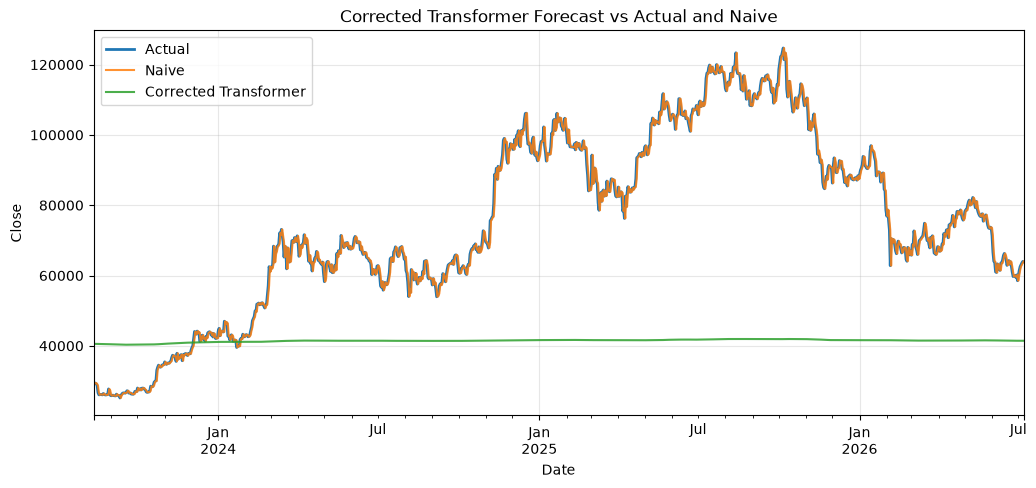

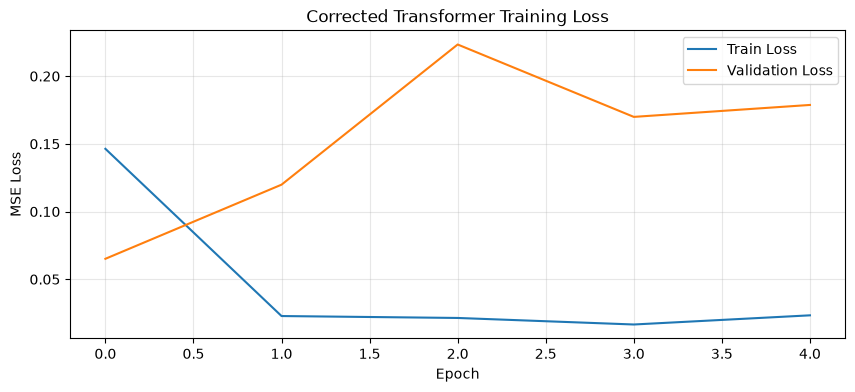

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Original LSTM,17999.812391,20912.972998,21.419551,24.421117
Improved LSTM,23436.695846,27049.622966,27.972044,33.257138
Corrected Transformer,35914.796968,42116.104248,43.491289,56.343025
Collapsed Transformer v1,65122.605617,69956.202009,84.344690,147.167945


In [14]:
D_MODEL = 64
NUM_HEADS = 4
FF_DIM = 128
DROPOUT_RATE = 0.1


def corrected_transformer_encoder(inputs, d_model=64, num_heads=4, ff_dim=128, dropout=0.1):
    attention_output = MultiHeadAttention(
        key_dim=d_model // num_heads,
        num_heads=num_heads,
        dropout=dropout,
    )(inputs, inputs)
    attention_output = Dropout(dropout)(attention_output)
    x = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    feed_forward = Dense(ff_dim, activation="relu")(x)
    feed_forward = Dropout(dropout)(feed_forward)
    feed_forward = Dense(d_model)(feed_forward)
    return LayerNormalization(epsilon=1e-6)(x + feed_forward)


corrected_inputs = Input(shape=(LOOKBACK, 1))
x = Dense(D_MODEL)(corrected_inputs)
x = corrected_transformer_encoder(
    x,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    dropout=DROPOUT_RATE,
)
x = GlobalAveragePooling1D()(x)
x = Dropout(DROPOUT_RATE)(x)
x = Dense(32, activation="relu")(x)
corrected_outputs = Dense(1)(x)

corrected_transformer_model = Model(corrected_inputs, corrected_outputs)
corrected_transformer_model.compile(optimizer="adam", loss="mse")
corrected_transformer_model.summary()

corrected_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

corrected_history = corrected_transformer_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[corrected_early_stopping],
    shuffle=False,
)

corrected_predictions_scaled = corrected_transformer_model.predict(X_test)
corrected_predictions = scaler.inverse_transform(corrected_predictions_scaled).ravel()
corrected_transformer_forecast = pd.Series(
    corrected_predictions,
    index=test.index,
    name="Corrected Transformer",
)

corrected_metrics = evaluate_forecast(y_test, corrected_transformer_forecast)
corrected_diagnostics = pd.DataFrame(
    {
        "Actual": y_test,
        "Corrected Transformer": corrected_transformer_forecast,
    }
)

print("First 10 actual values:")
print(y_test.head(10).to_string())

print("\nFirst 10 corrected Transformer predictions:")
print(corrected_transformer_forecast.head(10).to_string())

print("\nCorrected Transformer prediction min/max:")
print(corrected_transformer_forecast.min(), corrected_transformer_forecast.max())

print("\nCorrected Transformer prediction std:")
print(corrected_transformer_forecast.std())

print("\nCorrelation with actual:")
print(y_test.corr(corrected_transformer_forecast))

print("\nCorrected Transformer metrics:")
corrected_metrics_table = pd.DataFrame([corrected_metrics], index=["Corrected Transformer"])
print(corrected_metrics_table.to_string())

corrected_comparison_forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Original LSTM": original_lstm_forecast,
    "Improved LSTM": improved_lstm_forecast,
    "Collapsed Transformer v1": transformer_forecast,
    "Corrected Transformer": corrected_transformer_forecast,
}

corrected_comparison = pd.DataFrame(
    [evaluate_forecast(y_test, forecast) for forecast in corrected_comparison_forecasts.values()],
    index=corrected_comparison_forecasts.keys(),
)

print("\nCorrected model comparison:")
print(corrected_comparison.sort_values("RMSE").to_string())

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
naive_forecast.plot(ax=ax, label="Naive", alpha=0.85)
corrected_transformer_forecast.plot(ax=ax, label="Corrected Transformer", alpha=0.85)
ax.set_title("Corrected Transformer Forecast vs Actual and Naive")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(corrected_history.history["loss"], label="Train Loss")
ax.plot(corrected_history.history["val_loss"], label="Validation Loss")
ax.set_title("Corrected Transformer Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

corrected_comparison.sort_values("RMSE")


The corrected Transformer is structurally valid because attention, feed-forward layers, residual connections, and `LayerNormalization` now operate in a `d_model`-wide representation instead of a one-dimensional feature axis. The forecast should be treated as an experimental deep-learning benchmark rather than a guaranteed improvement over naive persistence: Bitcoin close prices are noisy, non-stationary, and often hard to beat with short univariate neural models. If the corrected predictions have non-zero variance and finite correlation/metrics, the collapse has been fixed; whether the model is useful depends on its comparison with the naive and moving-average baselines.